# 05. Hard Clamp vs Smooth Coulomb Gradient Pathology

After direction-only constraints failed, the next version introduced a Coulomb magnitude envelope. That fixed the missing scale constraint, but the early implementation used hard clipping. In PyTorch terms, the dangerous operation is `torch.clamp(raw_delta, -limit, limit)`.

Clamp protects the forward pass, but it damages the backward pass. When `raw_delta` is outside the allowed envelope, the derivative through clamp is zero. The network can be physically clipped into range while the offending logit receives no local gradient telling it how far it overshot. This is the dead-gradient zone.

The final `SmoothHardCoulombConstraint` changes the parameterization. The model predicts magnitude logits, then maps them with `sigmoid(logits) * envelope` and routes sign by current. The forward pass remains physically bounded, but the magnitude path has nonzero derivative for finite logits. That keeps optimization recoverable while preserving PVR = 0.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'logs').exists() and (candidate / 'outputs').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing src/, logs/, and outputs/.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / 'outputs' / 'figures' / 'ablation_studies'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.fontsize': 8.5,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
})
print(f'Project root: {ROOT}')
print(f'Figure output: {FIG_DIR}')


Project root: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC
Figure output: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies


## Load clamp and smooth ledgers

The clamp-era ledgers are Sprint 46. The smooth-era ledgers are Sprint 48 for LSTM and Sprint 52 for TCN. The comparison is not a claim that every hyperparameter is identical; it is the project chronology showing that smooth parameterization improved recovery while keeping zero PVR.


In [2]:
clamp_lstm_path = ROOT / 'logs' / 'sprint46_results_v5_coulomb.json'
clamp_tcn_path = ROOT / 'logs' / 'sprint46_results_v5_coulomb_tcn_all.json'
smooth_lstm_path = ROOT / 'outputs' / 'v7_final' / 'sprint48_evaluation_results.json'
smooth_tcn_path = ROOT / 'outputs' / 'v8_tcn_redemption' / 'sprint52' / 'sprint52_tcn_redemption_results.json'
for path in [clamp_lstm_path, clamp_tcn_path, smooth_lstm_path, smooth_tcn_path]:
    if not path.exists():
        raise FileNotFoundError(path)

clamp_lstm = json.loads(clamp_lstm_path.read_text(encoding='utf-8'))
clamp_tcn = json.loads(clamp_tcn_path.read_text(encoding='utf-8'))
smooth_lstm = json.loads(smooth_lstm_path.read_text(encoding='utf-8'))
smooth_tcn = json.loads(smooth_tcn_path.read_text(encoding='utf-8'))

def row(label, backbone, topology, scenario, metrics, source):
    return {
        'Model': label,
        'Backbone': backbone,
        'Topology': topology,
        'Scenario': scenario,
        'RMSE full (%)': float(metrics['rmse_full_pct']),
        'MaxE full (%)': float(metrics.get('max_error_full_pct', metrics.get('maxe_full_pct'))),
        'PVR (%)': float(metrics.get('pvr', metrics.get('pvr_pct'))),
        'Violations': int(metrics.get('pvr_violations', 0)),
        'Source': str(source.relative_to(ROOT)),
    }

smooth_lstm_a = [r for r in smooth_lstm if r['model_kind'] == 'hard_coulomb_lstm' and r['scenario'] == 'scenario_A'][0]['metrics']
smooth_tcn_a = [r for r in smooth_tcn['results'] if r.get('model') == 'HardCoulombTCN' and r.get('scenario') == 'scenario_A'][0]['metrics']
comparison = pd.DataFrame([
    row('Clamp Hard-Coulomb LSTM', 'LSTM', 'torch.clamp envelope', 'Scenario A', clamp_lstm['scenario_A'], clamp_lstm_path),
    row('Smooth Hard-Coulomb LSTM', 'LSTM', 'sigmoid magnitude envelope', 'Scenario A', smooth_lstm_a, smooth_lstm_path),
    row('Clamp Hard-Coulomb TCN', 'TCN', 'torch.clamp envelope', 'Scenario A', clamp_tcn['scenario_A'], clamp_tcn_path),
    row('Smooth Hard-Coulomb TCN', 'TCN', 'sigmoid magnitude envelope', 'Scenario A', smooth_tcn_a, smooth_tcn_path),
])
display(comparison.round({'RMSE full (%)': 3, 'MaxE full (%)': 3, 'PVR (%)': 6}))
assert (comparison['PVR (%)'] == 0.0).all(), 'All compared Hard-Coulomb variants should keep PVR zero.'
assert float(comparison[(comparison['Backbone'] == 'LSTM') & (comparison['Topology'].str.startswith('sigmoid'))]['MaxE full (%)'].iloc[0]) < float(comparison[(comparison['Backbone'] == 'LSTM') & (comparison['Topology'].str.startswith('torch'))]['MaxE full (%)'].iloc[0]), 'Smooth LSTM should improve MaxE versus clamp LSTM.'


,Model,Backbone,Topology,Scenario,RMSE full (%),MaxE full (%),PVR (%),Violations,Source
0,Clamp Hard-Coulomb LSTM,LSTM,torch.clamp envelope,Scenario A,10.418,70.823,0.0,0,logs\sprint46_results_v5_coulomb.json
1,Smooth Hard-Coulomb LSTM,LSTM,sigmoid magnitude envelope,Scenario A,12.711,55.113,0.0,0,outputs\v7_final\sprint48_evaluation_results.json
2,Clamp Hard-Coulomb TCN,TCN,torch.clamp envelope,Scenario A,12.115,79.480,0.0,0,logs\sprint46_results_v5_coulomb_tcn_all.json
3,Smooth Hard-Coulomb TCN,TCN,sigmoid magnitude envelope,Scenario A,11.459,46.730,0.0,0,outputs\v8_tcn_redemption\sprint52\sprint52_tc...


## Dead-gradient visualization

The left panel shows the optimization pathology. Clamp has exactly zero derivative outside the envelope. Sigmoid magnitude has a bounded forward output but keeps a nonzero derivative for finite logits. The right panel shows the empirical MaxE recovery from the project ledgers.


In [3]:
x = np.linspace(-4.0, 4.0, 401)
limit = 1.0
clamp_forward = np.clip(x, -limit, limit)
clamp_grad = ((x >= -limit) & (x <= limit)).astype(float)
sigmoid = 1.0 / (1.0 + np.exp(-x))
smooth_forward = limit * sigmoid
smooth_grad = limit * sigmoid * (1.0 - sigmoid)
gradient_df = pd.DataFrame({
    'Input region': ['far below envelope', 'inside envelope', 'far above envelope'],
    'Clamp derivative': [float(clamp_grad[0]), float(clamp_grad[len(clamp_grad)//2]), float(clamp_grad[-1])],
    'Smooth derivative': [float(smooth_grad[0]), float(smooth_grad[len(smooth_grad)//2]), float(smooth_grad[-1])],
})
display(gradient_df.round(6))


,Input region,Clamp derivative,Smooth derivative
0,far below envelope,0.0,0.017663
1,inside envelope,1.0,0.250000
2,far above envelope,0.0,0.017663


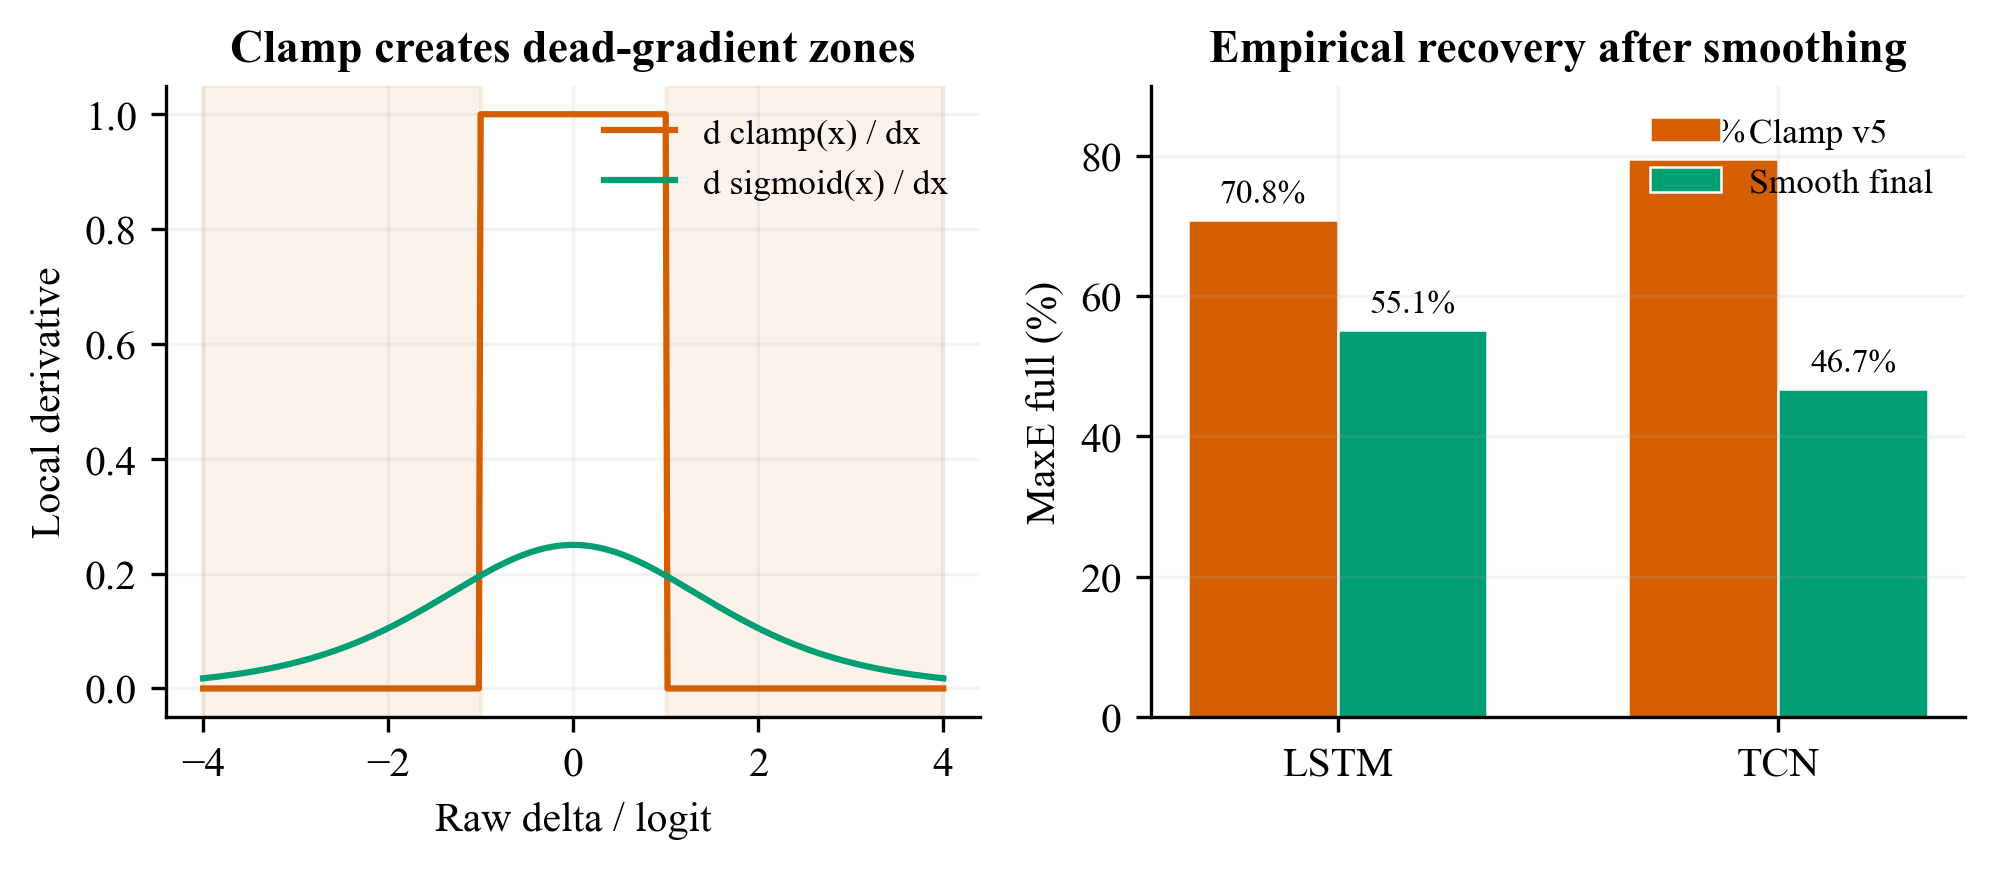

Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_05_clamp_vs_smooth_gradient_pathology.pdf
Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_05_clamp_vs_smooth_gradient_pathology.png


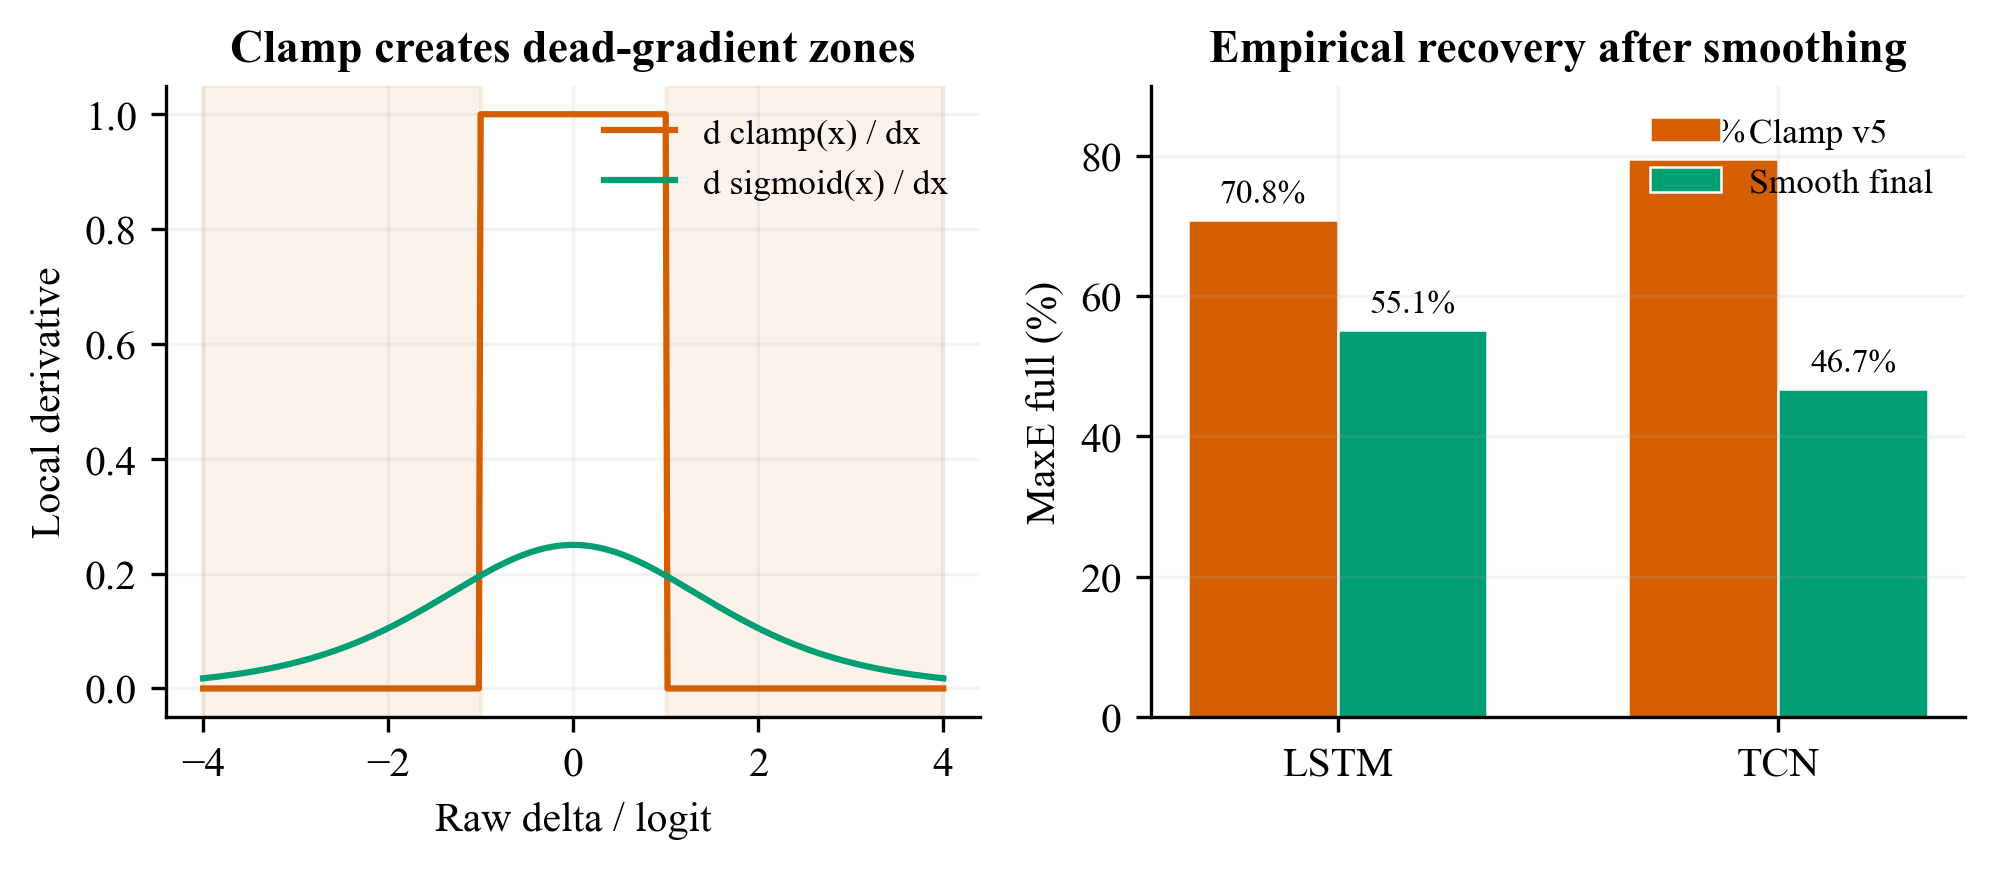

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(6.75, 3.0))
ax = axes[0]
ax.plot(x, clamp_grad, color='#D55E00', label='d clamp(x) / dx')
ax.plot(x, smooth_grad, color='#009E73', label='d sigmoid(x) / dx')
ax.axvspan(-4, -1, color='#D55E00', alpha=0.08)
ax.axvspan(1, 4, color='#D55E00', alpha=0.08)
ax.set_xlabel('Raw delta / logit')
ax.set_ylabel('Local derivative')
ax.set_title('Clamp creates dead-gradient zones')
ax.legend(loc='upper right')

bar_ax = axes[1]
pivot = comparison.pivot(index='Backbone', columns='Topology', values='MaxE full (%)').loc[['LSTM', 'TCN']]
bar_x = np.arange(len(pivot.index))
width = 0.34
clamp_vals = pivot['torch.clamp envelope'].to_numpy(dtype=float)
smooth_vals = pivot['sigmoid magnitude envelope'].to_numpy(dtype=float)
bars1 = bar_ax.bar(bar_x - width/2, clamp_vals, width=width, color='#D55E00', edgecolor='white', linewidth=0.6, label='Clamp v5')
bars2 = bar_ax.bar(bar_x + width/2, smooth_vals, width=width, color='#009E73', edgecolor='white', linewidth=0.6, label='Smooth final')
for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()
        bar_ax.text(bar.get_x() + bar.get_width()/2, value + 1.5, f'{value:.1f}%', ha='center', va='bottom', fontsize=8)
bar_ax.set_xticks(bar_x)
bar_ax.set_xticklabels(pivot.index)
bar_ax.set_ylabel('MaxE full (%)')
bar_ax.set_ylim(0, max(90.0, max(clamp_vals.max(), smooth_vals.max()) + 10))
bar_ax.set_title('Empirical recovery after smoothing')
bar_ax.legend(loc='upper right')
fig.tight_layout()
pdf_path = FIG_DIR / 'fig_05_clamp_vs_smooth_gradient_pathology.pdf'
png_path = FIG_DIR / 'fig_05_clamp_vs_smooth_gradient_pathology.png'
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=300)
display(fig)
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')


## Autopsy

Clamp solved forward-pass safety but created optimizer blind spots. Smooth sigmoid magnitude keeps the same physical envelope while making the trainable parameter a logit with live gradients. That is the final topology: hard safety in the forward pass, differentiable recovery in the backward pass.
